# U-Net Instance Segmentation — Solar Panel Detection (`hassolar`)

Trains a U-Net on the CVAT/COCO-format solar-panel annotations (`merged_instances_default.json`) by rasterizing the polygon annotations into pixel masks, then derives per-instance predictions via connected-component post-processing so detection-style metrics (mAP@50, mAP@95) can be reported alongside standard pixel metrics.



In [2]:
import os
import json
import glob
import time
import csv
import random
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [3]:
print("✅ Imports successful")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not detected")

✅ Imports successful
PyTorch version: 2.14.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [3]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Config — edit paths here

In [4]:
# ============================================================
# CONFIG — U-Net
# ============================================================

MODEL_NAME = "UNet"

BASE_DIR = r"D:\SolarMap-India"

DATA_DIR = os.path.join(
    BASE_DIR,
    "dataset",
    "Solar Images",
    "Solar Images"
)

IMAGE_DIR = os.path.join(
    DATA_DIR,
    "images",
    "default"
)

ANNOTATION_FILE = os.path.join(
    DATA_DIR,
    "annotations",
    "merged_instances_default.json"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "UNet"
)

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

IMG_SIZE = 256
NUM_CLASSES = 2
BATCH_SIZE = 8
LR = 1e-4
EPOCHS = 50
SEED = 42

print("=" * 70)
print("U-NET CONFIGURATION")
print("=" * 70)
print("Model:", MODEL_NAME)
print("Image directory:", IMAGE_DIR)
print("Annotation file:", ANNOTATION_FILE)
print("Output directory:", OUTPUT_DIR)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)
print("Epochs:", EPOCHS)

U-NET CONFIGURATION
Model: UNet
Image directory: D:\SolarMap-India\dataset\Solar Images\Solar Images\images\default
Annotation file: D:\SolarMap-India\dataset\Solar Images\Solar Images\annotations\merged_instances_default.json
Output directory: D:\SolarMap-India\outputs\UNet
Image size: 256
Batch size: 8
Learning rate: 0.0001
Epochs: 50


## Load COCO annotations & build the train / val / test split

In [5]:
# =========================================================
# LOAD COCO DATASET
# =========================================================

with open(ANNOTATIONS_JSON, "r") as f:
    coco = json.load(f)

# ---------------------------------------------------------
# Categories
# ---------------------------------------------------------

categories = {
    c["id"]: c["name"]
    for c in coco["categories"]
}

print("Categories:", categories)

# ---------------------------------------------------------
# Images
# ---------------------------------------------------------

images_by_id = {
    img["id"]: img
    for img in coco["images"]
}

# ---------------------------------------------------------
# Group annotations by image ID
# ---------------------------------------------------------

annotations_by_image = {}

for ann in coco["annotations"]:
    annotations_by_image.setdefault(
        ann["image_id"], []
    ).append(ann)

# ---------------------------------------------------------
# Dataset statistics
# ---------------------------------------------------------

print(f"Total images in JSON: {len(images_by_id)}")
print(f"Total annotations in JSON: {len(coco['annotations'])}")
print(
    f"Images with at least one annotation: "
    f"{len(annotations_by_image)}"
)

# ---------------------------------------------------------
# Keep only images that actually exist on disk
# ---------------------------------------------------------

valid_image_ids = []
missing = 0

for image_id, entry in images_by_id.items():

    image_path = os.path.join(
        IMAGES_DIR,
        entry["file_name"]
    )

    if os.path.isfile(image_path):
        valid_image_ids.append(image_id)
    else:
        missing += 1

if missing:
    print(
        f"Warning: {missing} images listed in the JSON "
        f"were not found in:\n{IMAGES_DIR}\n"
        f"Those images will be skipped."
    )

print(f"Usable images: {len(valid_image_ids)}")

print("=" * 60)
print("COCO dataset loaded successfully.")
print("=" * 60)

NameError: name 'ANNOTATIONS_JSON' is not defined

In [19]:
# U-Net metrics directory
METRICS_DIR = os.path.join(
    OUTPUT_DIR,
    "metrics"
)

os.makedirs(METRICS_DIR, exist_ok=True)

print("METRICS_DIR:", METRICS_DIR)

METRICS_DIR: D:\SolarMap-India\outputs\UNet\metrics


In [20]:
# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

rng = random.Random(SEED)

# Copy before shuffling so valid_image_ids is unchanged
shuffled_ids = valid_image_ids[:]
rng.shuffle(shuffled_ids)

# ---------------------------------------------------------
# Calculate split sizes
# ---------------------------------------------------------

n_total = len(shuffled_ids)

n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)

# ---------------------------------------------------------
# Create splits
# ---------------------------------------------------------

train_ids = shuffled_ids[:n_train]

val_ids = shuffled_ids[
    n_train:n_train + n_val
]

test_ids = shuffled_ids[
    n_train + n_val:
]

# ---------------------------------------------------------
# Validate split sizes
# ---------------------------------------------------------

assert len(train_ids) + len(val_ids) + len(test_ids) == n_total

assert len(set(train_ids).intersection(val_ids)) == 0
assert len(set(train_ids).intersection(test_ids)) == 0
assert len(set(val_ids).intersection(test_ids)) == 0

# ---------------------------------------------------------
# Print split information
# ---------------------------------------------------------

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print(f"Total: {n_total}")
print(f"Train: {len(train_ids)}")
print(f"Val:   {len(val_ids)}")
print(f"Test:  {len(test_ids)}")

print("-" * 60)

print(
    f"Actual ratios: "
    f"{len(train_ids)/n_total:.4f} / "
    f"{len(val_ids)/n_total:.4f} / "
    f"{len(test_ids)/n_total:.4f}"
)

# ---------------------------------------------------------
# Save split
# ---------------------------------------------------------

split_path = os.path.join(
    METRICS_DIR,
    "split_image_ids.json"
)

with open(split_path, "w") as f:
    json.dump(
        {
            "train": train_ids,
            "val": val_ids,
            "test": test_ids
        },
        f,
        indent=2
    )

print("-" * 60)
print(f"Saved split to: {split_path}")
print("=" * 60)
print("Dataset split created successfully.")

DATASET SPLIT
Total: 2500
Train: 1750
Val:   375
Test:  375
------------------------------------------------------------
Actual ratios: 0.7000 / 0.1500 / 0.1500
------------------------------------------------------------
Saved split to: D:\SolarMap-India\outputs\UNet\metrics\split_image_ids.json
Dataset split created successfully.


## Mask utilities (COCO polygon → raster mask)

In [21]:
# =========================================================
# COCO POLYGON → MASK UTILITIES
# =========================================================

def polygons_to_mask(segmentations, height, width):
    """
    Rasterize COCO polygons into a binary mask.

    Parameters
    ----------
    segmentations : list
        COCO polygon segmentations.
    height : int
        Original image height.
    width : int
        Original image width.

    Returns
    -------
    np.ndarray
        Binary mask of shape (height, width).
    """
    mask_img = Image.new(
        "L",
        (width, height),
        0
    )

    draw = ImageDraw.Draw(mask_img)

    for poly in segmentations:

        if len(poly) < 6:
            continue

        xy = list(
            zip(
                poly[0::2],
                poly[1::2]
            )
        )

        draw.polygon(
            xy,
            outline=1,
            fill=1
        )

    return np.array(
        mask_img,
        dtype=np.uint8
    )


def semantic_mask_for_image(image_entry, anns):
    """
    Create a combined binary semantic mask.

    All valid solar-panel instances are merged
    into a single foreground class.
    """

    h = image_entry["height"]
    w = image_entry["width"]

    mask = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    for ann in anns:

        seg = ann.get(
            "segmentation",
            []
        )

        # Ignore empty/crowd annotations
        if not seg or ann.get("iscrowd", 0) == 1:
            continue

        inst_mask = polygons_to_mask(
            seg,
            h,
            w
        )

        mask = np.maximum(
            mask,
            inst_mask
        )

    return mask


def instance_masks_for_image(image_entry, anns, out_size):
    """
    Create individual instance masks.

    These masks are used only for
    instance-level evaluation.
    """

    h = image_entry["height"]
    w = image_entry["width"]

    masks = []

    for ann in anns:

        seg = ann.get(
            "segmentation",
            []
        )

        # Ignore empty/crowd annotations
        if not seg or ann.get("iscrowd", 0) == 1:
            continue

        inst_mask = polygons_to_mask(
            seg,
            h,
            w
        )

        # Skip completely empty masks
        if inst_mask.sum() == 0:
            continue

        resized = np.array(
            Image.fromarray(
                inst_mask * 255
            ).resize(
                (out_size, out_size),
                resample=Image.NEAREST
            )
        ) > 127

        masks.append(resized)

    return masks


print("COCO mask utilities defined successfully.")

COCO mask utilities defined successfully.


## Dataset

In [22]:
class SolarPanelDataset(Dataset):
    def __init__(self, image_ids, images_by_id, annotations_by_image, images_dir, img_size=256):
        self.image_ids = image_ids
        self.images_by_id = images_by_id
        self.annotations_by_image = annotations_by_image
        self.images_dir = images_dir
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        entry = self.images_by_id[image_id]
        anns = self.annotations_by_image.get(image_id, [])

        image_path = os.path.join(self.images_dir, entry["file_name"])
        image = Image.open(image_path).convert("RGB")
        image = self.img_transform(image)

        mask = semantic_mask_for_image(entry, anns)
        mask_img = Image.fromarray(mask * 255)
        mask_img = mask_img.resize((self.img_size, self.img_size), resample=Image.NEAREST)
        mask = (np.array(mask_img) > 127).astype(np.int64)
        mask = torch.from_numpy(mask)

        return image, mask, image_id


## U-Net model

In [23]:
# =========================================================
# U-NET MODEL ARCHITECTURE
# =========================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(
        self,
        num_classes=2,
        in_channels=3,
        base_channels=32
    ):
        super().__init__()

        c = base_channels

        # -------------------------------------------------
        # Encoder
        # -------------------------------------------------

        self.enc1 = DoubleConv(
            in_channels,
            c
        )

        self.enc2 = DoubleConv(
            c,
            c * 2
        )

        self.enc3 = DoubleConv(
            c * 2,
            c * 4
        )

        self.enc4 = DoubleConv(
            c * 4,
            c * 8
        )

        # -------------------------------------------------
        # Bottleneck
        # -------------------------------------------------

        self.bottleneck = DoubleConv(
            c * 8,
            c * 16
        )

        # -------------------------------------------------
        # Pooling
        # -------------------------------------------------

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # -------------------------------------------------
        # Decoder
        # -------------------------------------------------

        self.up4 = nn.ConvTranspose2d(
            c * 16,
            c * 8,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            c * 16,
            c * 8
        )

        self.up3 = nn.ConvTranspose2d(
            c * 8,
            c * 4,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            c * 8,
            c * 4
        )

        self.up2 = nn.ConvTranspose2d(
            c * 4,
            c * 2,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            c * 4,
            c * 2
        )

        self.up1 = nn.ConvTranspose2d(
            c * 2,
            c,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            c * 2,
            c
        )

        # -------------------------------------------------
        # Pixel-wise classifier
        # -------------------------------------------------

        self.classifier = nn.Conv2d(
            c,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        # -------------------------------------------------
        # Encoder
        # -------------------------------------------------

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        e4 = self.enc4(
            self.pool(e3)
        )

        # -------------------------------------------------
        # Bottleneck
        # -------------------------------------------------

        b = self.bottleneck(
            self.pool(e4)
        )

        # -------------------------------------------------
        # Decoder
        # -------------------------------------------------

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # -------------------------------------------------
        # Output
        # -------------------------------------------------

        out = self.classifier(d1)

        return out


print("U-Net architecture defined successfully.")

U-Net architecture defined successfully.


## Losses & pixel-wise metrics

In [24]:
# =========================================================
# LOSS + METRICS + U-NET INITIALIZATION
# =========================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        num_classes = logits.shape[1]

        probs = torch.softmax(
            logits,
            dim=1
        )

        targets_one_hot = F.one_hot(
            targets.long(),
            num_classes=num_classes
        ).permute(
            0, 3, 1, 2
        ).float()

        dims = (0, 2, 3)

        intersection = torch.sum(
            probs * targets_one_hot,
            dims
        )

        cardinality = torch.sum(
            probs + targets_one_hot,
            dims
        )

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            cardinality + self.smooth
        )

        return 1.0 - dice.mean()


class SegmentationMetrics:
    """
    Pixel-wise accuracy, precision, recall,
    F1, IoU and Dice.
    """

    def __init__(
        self,
        num_classes,
        ignore_index=None,
        eps=1e-7
    ):
        self.num_classes = int(num_classes)
        self.ignore_index = ignore_index
        self.eps = eps

        self.reset()

    def reset(self):

        self.tp = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.fp = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.fn = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.correct = 0
        self.total = 0

    def update(self, logits, targets):

        preds = torch.argmax(
            logits,
            dim=1
        )

        targets = targets.long()

        if self.ignore_index is not None:

            valid_mask = (
                targets != self.ignore_index
            )

            preds = preds[valid_mask]
            targets = targets[valid_mask]

        self.correct += (
            preds == targets
        ).sum().item()

        self.total += targets.numel()

        for cls in range(self.num_classes):

            pred_cls = preds == cls
            target_cls = targets == cls

            self.tp[cls] += (
                pred_cls & target_cls
            ).sum().item()

            self.fp[cls] += (
                pred_cls & ~target_cls
            ).sum().item()

            self.fn[cls] += (
                ~pred_cls & target_cls
            ).sum().item()

    def compute(self):

        precision = (
            self.tp /
            (self.tp + self.fp + self.eps)
        )

        recall = (
            self.tp /
            (self.tp + self.fn + self.eps)
        )

        f1 = (
            2 * precision * recall /
            (precision + recall + self.eps)
        )

        iou = (
            self.tp /
            (
                self.tp +
                self.fp +
                self.fn +
                self.eps
            )
        )

        dice = (
            2 * self.tp /
            (
                2 * self.tp +
                self.fp +
                self.fn +
                self.eps
            )
        )

        accuracy = (
            self.correct /
            max(self.total, 1)
        )

        return {
            "accuracy": float(accuracy),
            "precision": float(precision.mean()),
            "recall": float(recall.mean()),
            "f1": float(f1.mean()),
            "iou": float(iou.mean()),
            "dice": float(dice.mean()),
            "dice_loss": float(
                1.0 - dice.mean()
            )
        }


# =========================================================
# INITIALIZE U-NET
# =========================================================

model = UNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

criterion_ce = nn.CrossEntropyLoss()

criterion_dice = DiceLoss()


# =========================================================
# MODEL SUMMARY
# =========================================================

num_parameters = sum(
    p.numel()
    for p in model.parameters()
)

print("=" * 60)
print("U-NET INITIALIZED")
print("=" * 60)
print(f"Model parameters: {num_parameters:,}")
print("Model:", type(model).__name__)
print("Device:", DEVICE)
print("Learning rate:", LEARNING_RATE)
print("Optimizer:", type(optimizer).__name__)
print("Scheduler:", type(scheduler).__name__)
print("Loss: CrossEntropyLoss + DiceLoss")
print("=" * 60)

U-NET INITIALIZED
Model parameters: 7,766,018
Model: UNet
Device: cuda
Learning rate: 0.0001
Optimizer: Adam
Scheduler: ReduceLROnPlateau
Loss: CrossEntropyLoss + DiceLoss


## DataLoaders

In [26]:
num_workers = 0

train_dataset = SolarPanelDataset(train_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
val_dataset = SolarPanelDataset(val_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
test_dataset = SolarPanelDataset(test_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)

def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    image_ids = [b[2] for b in batch]
    return images, masks, image_ids

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                           collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                         collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                          collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 1750
Val samples: 375
Test samples: 375


## Training utilities (pixel-level metrics, run every epoch)

In [34]:
torch.backends.cudnn.benchmark = True

print("cuDNN benchmark:", torch.backends.cudnn.benchmark)

cuDNN benchmark: True


In [27]:
# =========================================================
# CLEAN TRAINING / VALIDATION EPOCH FUNCTION
# =========================================================

def run_epoch(loader, model, optimizer=None):

    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    metrics = SegmentationMetrics(
        NUM_CLASSES,
        ignore_index=IGNORE_INDEX
    )

    total_loss = 0.0
    total_samples = 0

    for images, masks, _image_ids in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        ).long()

        if is_train:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(is_train):

            outputs = model(images)

            ce_loss = criterion_ce(
                outputs,
                masks
            )

            dice_loss = criterion_dice(
                outputs,
                masks
            )

            loss = ce_loss + dice_loss

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)

        total_loss += (
            loss.detach().item() * batch_size
        )

        total_samples += batch_size

        metrics.update(
            outputs.detach(),
            masks
        )

    avg_loss = (
        total_loss /
        max(total_samples, 1)
    )

    return avg_loss, metrics.compute()


def format_metrics(name, metrics):

    return (
        f"{name}: "
        f"acc={metrics['accuracy']:.4f} | "
        f"prec={metrics['precision']:.4f} | "
        f"recall={metrics['recall']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"dice={metrics['dice']:.4f} | "
        f"iou={metrics['iou']:.4f} | "
        f"dice_loss={metrics['dice_loss']:.4f}"
    )


print("Clean training utilities defined successfully.")

Clean training utilities defined successfully.


In [31]:
print("Kernel is free")

Kernel is free


In [32]:
# =========================================================
# FORCE U-NET OUTPUT PATHS
# =========================================================

MODEL_SAVE_DIR = r"D:\SolarMap-India\outputs\UNet\models"
METRICS_DIR = r"D:\SolarMap-India\outputs\UNet\metrics"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

print("MODEL_SAVE_DIR =", MODEL_SAVE_DIR)
print("METRICS_DIR    =", METRICS_DIR)

assert "UNet" in MODEL_SAVE_DIR
assert "DilatedNet" not in MODEL_SAVE_DIR

print("✓ Output paths are correctly set to U-Net")

MODEL_SAVE_DIR = D:\SolarMap-India\outputs\UNet\models
METRICS_DIR    = D:\SolarMap-India\outputs\UNet\metrics
✓ Output paths are correctly set to U-Net


## Training loop

In [33]:
# =========================================================
# U-NET — OFFICIAL 50-EPOCH TRAINING
# =========================================================

# ---------------------------------------------------------
# Reset model, optimizer and scheduler
# Ensures a completely fresh official 50-epoch run
# ---------------------------------------------------------

model = UNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

# ---------------------------------------------------------
# Training history
# ---------------------------------------------------------

history = {
    "train_loss": [],
    "val_loss": [],
    "train_metrics": [],
    "val_metrics": []
}

best_val_loss = float("inf")

# ---------------------------------------------------------
# Output files
# ---------------------------------------------------------

best_model_path = os.path.join(
    MODEL_SAVE_DIR,
    "unet_best.pth"
)

train_metrics_path = os.path.join(
    METRICS_DIR,
    "metrics_train_val_per_epoch.csv"
)

# ---------------------------------------------------------
# Start training
# ---------------------------------------------------------

train_start = time.time()

print("=" * 70)
print("U-NET — OFFICIAL 50-EPOCH TRAINING")
print("=" * 70)

print(
    "Training start:",
    time.strftime(
        "%Y-%m-%d %H:%M:%S",
        time.localtime(train_start)
    )
)

print("Model:", type(model).__name__)
print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Best model:", best_model_path)

print("=" * 70)

# ---------------------------------------------------------
# CSV file
# ---------------------------------------------------------

with open(
    train_metrics_path,
    "w",
    newline=""
) as metrics_file:

    writer = csv.writer(metrics_file)

    writer.writerow([
        "epoch",
        "split",
        "loss",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "dice",
        "iou",
        "dice_loss"
    ])

    # =====================================================
    # 50 EPOCHS
    # =====================================================

    for epoch in range(EPOCHS):

        epoch_start = time.time()

        # -------------------------------------------------
        # Training
        # -------------------------------------------------

        train_loss, train_metrics = run_epoch(
            train_loader,
            model,
            optimizer=optimizer
        )

        # -------------------------------------------------
        # Validation
        # -------------------------------------------------

        val_loss, val_metrics = run_epoch(
            val_loader,
            model,
            optimizer=None
        )

        # -------------------------------------------------
        # Learning-rate scheduler
        # -------------------------------------------------

        scheduler.step(val_loss)

        # -------------------------------------------------
        # Store history
        # -------------------------------------------------

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_metrics"].append(
            train_metrics
        )

        history["val_metrics"].append(
            val_metrics
        )

        # -------------------------------------------------
        # Save metrics to CSV
        # -------------------------------------------------

        for split_name, loss_value, metrics in [
            ("train", train_loss, train_metrics),
            ("val", val_loss, val_metrics)
        ]:

            writer.writerow([
                epoch + 1,
                split_name,
                loss_value,
                metrics["accuracy"],
                metrics["precision"],
                metrics["recall"],
                metrics["f1"],
                metrics["dice"],
                metrics["iou"],
                metrics["dice_loss"]
            ])

        metrics_file.flush()

        # -------------------------------------------------
        # Epoch results
        # -------------------------------------------------

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"\nEpoch {epoch + 1}/{EPOCHS} | "
            f"LR={current_lr:.2e}"
        )

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f}"
        )

        print(
            format_metrics(
                "Train",
                train_metrics
            )
        )

        print(
            format_metrics(
                "Val  ",
                val_metrics
            )
        )

        print(
            f"Epoch time: "
            f"{time.time() - epoch_start:.1f}s"
        )

        # -------------------------------------------------
        # Save best validation-loss model
        # -------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": best_val_loss
                },
                best_model_path
            )

            print(
                f"✓ Saved best model "
                f"(val_loss={best_val_loss:.4f})"
            )

# ---------------------------------------------------------
# Training completed
# ---------------------------------------------------------

train_end = time.time()

print("\n" + "=" * 70)
print("U-NET TRAINING COMPLETED")
print("=" * 70)

print(
    "Training end:",
    time.strftime(
        "%Y-%m-%d %H:%M:%S",
        time.localtime(train_end)
    )
)

print(
    f"Total training time: "
    f"{train_end - train_start:.1f}s"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best model saved to:\n"
    f"{best_model_path}"
)


print(
    f"Training metrics saved to:\n"
    f"{train_metrics_path}"
)

print("=" * 70)

U-NET — OFFICIAL 50-EPOCH TRAINING
Training start: 2026-10-07 13:59:50
Model: UNet
Device: cuda
Epochs: 50
Batch size: 8
Learning rate: 0.0001
Best model: D:\SolarMap-India\outputs\UNet\models\unet_best.pth

Epoch 1/50 | LR=1.00e-04
Train loss: 0.8749 | Val loss: 0.6784
Train: acc=0.9233 | prec=0.6749 | recall=0.8133 | f1=0.7191 | dice=0.7191 | iou=0.6180 | dice_loss=0.2809
Val  : acc=0.9698 | prec=0.8733 | recall=0.8072 | f1=0.8366 | dice=0.8366 | iou=0.7472 | dice_loss=0.1634
Epoch time: 259.2s
✓ Saved best model (val_loss=0.6784)

Epoch 2/50 | LR=1.00e-04
Train loss: 0.6370 | Val loss: 0.5733
Train: acc=0.9682 | prec=0.8264 | recall=0.8690 | f1=0.8462 | dice=0.8462 | iou=0.7582 | dice_loss=0.1538
Val  : acc=0.9668 | prec=0.8200 | recall=0.8984 | f1=0.8542 | dice=0.8542 | iou=0.7676 | dice_loss=0.1458
Epoch time: 258.2s
✓ Saved best model (val_loss=0.5733)

Epoch 3/50 | LR=1.00e-04
Train loss: 0.5168 | Val loss: 0.4859
Train: acc=0.9712 | prec=0.8399 | recall=0.8858 | f1=0.8611 | dic

KeyboardInterrupt: 

In [36]:
# =========================================================
# RESUME U-NET TRAINING — EPOCH 11 TO 50
# =========================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_metrics": [],
    "val_metrics": []
}

train_metrics_path = os.path.join(
    METRICS_DIR,
    "metrics_train_val_resume.csv"
)

train_start = time.time()

print("=" * 70)
print("U-NET — RESUMED TRAINING")
print("=" * 70)
print(f"Starting from epoch: {start_epoch + 1}")
print(f"Training until epoch: {EPOCHS}")
print(f"Best validation loss so far: {best_val_loss:.6f}")
print("=" * 70)

with open(
    train_metrics_path,
    "w",
    newline=""
) as metrics_file:

    writer = csv.writer(metrics_file)

    writer.writerow([
        "epoch",
        "split",
        "loss",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "dice",
        "iou",
        "dice_loss"
    ])

    # -----------------------------------------------------
    # Resume from Epoch 11
    # -----------------------------------------------------

    for epoch in range(start_epoch, EPOCHS):

        epoch_start = time.time()

        # -------------------------------------------------
        # Training
        # -------------------------------------------------

        train_loss, train_metrics = run_epoch(
            train_loader,
            model,
            optimizer=optimizer
        )

        # -------------------------------------------------
        # Validation
        # -------------------------------------------------

        val_loss, val_metrics = run_epoch(
            val_loader,
            model,
            optimizer=None
        )

        # -------------------------------------------------
        # Scheduler
        # -------------------------------------------------

        scheduler.step(val_loss)

        # -------------------------------------------------
        # Store history
        # -------------------------------------------------

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_metrics"].append(
            train_metrics
        )

        history["val_metrics"].append(
            val_metrics
        )

        # -------------------------------------------------
        # Save metrics
        # -------------------------------------------------

        for split_name, loss_value, metrics in [
            ("train", train_loss, train_metrics),
            ("val", val_loss, val_metrics)
        ]:

            writer.writerow([
                epoch + 1,
                split_name,
                loss_value,
                metrics["accuracy"],
                metrics["precision"],
                metrics["recall"],
                metrics["f1"],
                metrics["dice"],
                metrics["iou"],
                metrics["dice_loss"]
            ])

        metrics_file.flush()

        # -------------------------------------------------
        # Display
        # -------------------------------------------------

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"\nEpoch {epoch + 1}/{EPOCHS} | "
            f"LR={current_lr:.2e}"
        )

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f}"
        )

        print(
            format_metrics(
                "Train",
                train_metrics
            )
        )

        print(
            format_metrics(
                "Val  ",
                val_metrics
            )
        )

        print(
            f"Epoch time: "
            f"{time.time() - epoch_start:.1f}s"
        )

        # -------------------------------------------------
        # Save new best model
        # -------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": best_val_loss
                },
                checkpoint_path
            )

            print(
                f"✓ Saved new best model "
                f"(val_loss={best_val_loss:.6f})"
            )

# ---------------------------------------------------------
# Completed
# ---------------------------------------------------------

train_end = time.time()

print("\n" + "=" * 70)
print("U-NET RESUMED TRAINING COMPLETED")
print("=" * 70)

print(
    f"Total resume time: "
    f"{train_end - train_start:.1f}s"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

print(
    f"Best model: {checkpoint_path}"
)

print(
    f"Metrics: {train_metrics_path}"
)

print("=" * 70)

U-NET — RESUMED TRAINING
Starting from epoch: 11
Training until epoch: 50
Best validation loss so far: 0.240873

Epoch 11/50 | LR=1.00e-04
Train loss: 0.1626 | Val loss: 0.2492
Train: acc=0.9844 | prec=0.9230 | recall=0.9154 | f1=0.9192 | dice=0.9192 | iou=0.8589 | dice_loss=0.0808
Val  : acc=0.9734 | prec=0.8678 | recall=0.8712 | f1=0.8695 | dice=0.8695 | iou=0.7880 | dice_loss=0.1305
Epoch time: 134.0s

Epoch 12/50 | LR=1.00e-04
Train loss: 0.1536 | Val loss: 0.2482
Train: acc=0.9850 | prec=0.9262 | recall=0.9174 | f1=0.9218 | dice=0.9218 | iou=0.8628 | dice_loss=0.0782
Val  : acc=0.9745 | prec=0.8881 | recall=0.8497 | f1=0.8678 | dice=0.8678 | iou=0.7861 | dice_loss=0.1322
Epoch time: 129.1s

Epoch 13/50 | LR=1.00e-04
Train loss: 0.1390 | Val loss: 0.2398
Train: acc=0.9862 | prec=0.9320 | recall=0.9247 | f1=0.9283 | dice=0.9283 | iou=0.8730 | dice_loss=0.0717
Val  : acc=0.9752 | prec=0.8886 | recall=0.8584 | f1=0.8728 | dice=0.8728 | iou=0.7927 | dice_loss=0.1272
Epoch time: 126.1s


In [35]:
# =========================================================
# RESUME U-NET TRAINING FROM BEST CHECKPOINT
# =========================================================

checkpoint_path = r"D:\SolarMap-India\outputs\UNet\models\unet_best.pth"

# ---------------------------------------------------------
# Create fresh U-Net
# ---------------------------------------------------------

model = UNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

# ---------------------------------------------------------
# Create optimizer
# ---------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ---------------------------------------------------------
# Create scheduler
# ---------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

# ---------------------------------------------------------
# Loss functions
# ---------------------------------------------------------

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

# ---------------------------------------------------------
# Load checkpoint
# ---------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["val_loss"]

print("=" * 70)
print("U-NET CHECKPOINT LOADED")
print("=" * 70)
print("Checkpoint:", checkpoint_path)
print("Resume from epoch:", start_epoch)
print("Next epoch:", start_epoch + 1)
print("Best validation loss:", best_val_loss)
print("Current learning rate:", optimizer.param_groups[0]["lr"])
print("=" * 70)

U-NET CHECKPOINT LOADED
Checkpoint: D:\SolarMap-India\outputs\UNet\models\unet_best.pth
Resume from epoch: 10
Next epoch: 11
Best validation loss: 0.24087337803840636
Current learning rate: 0.0001


In [34]:
import os
import torch

checkpoint_path = r"D:\SolarMap-India\outputs\UNet\models\unet_best.pth"

print("Checkpoint exists:", os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )
    print("Saved epoch:", checkpoint["epoch"])
    print("Best validation loss:", checkpoint["val_loss"])

Checkpoint exists: True
Saved epoch: 10
Best validation loss: 0.24087337803840636


## Training curves

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\SolarMap-India\\outputs\\DilatedNet\\plots\\training_curves.png'

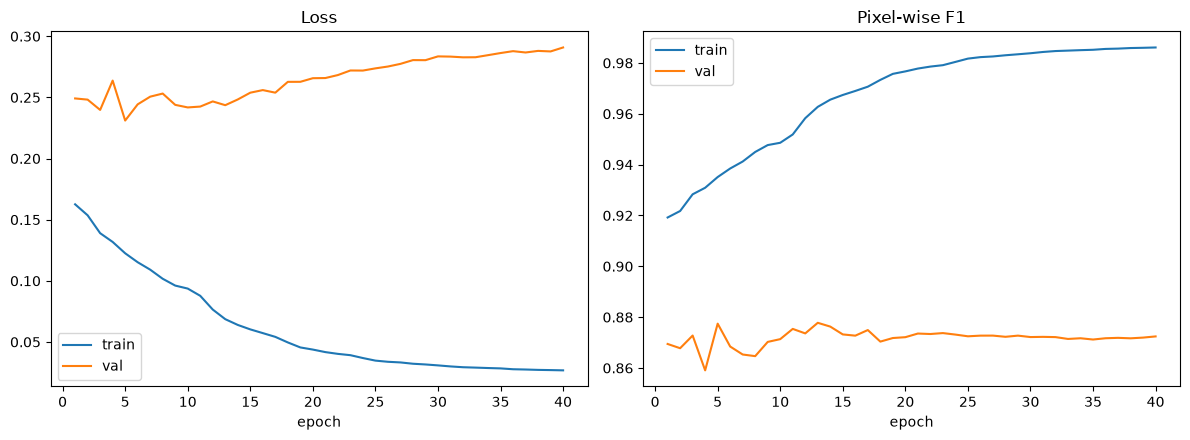

In [37]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

train_f1 = [m["f1"] for m in history["train_metrics"]]
val_f1 = [m["f1"] for m in history["val_metrics"]]
axes[1].plot(epochs_range, train_f1, label="train")
axes[1].plot(epochs_range, val_f1, label="val")
axes[1].set_title("Pixel-wise F1")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, "training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved training curves to {curve_path}")


## Final metrics: pixel + instance (mAP) for train / val / test

In [ ]:
if os.path.isfile(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from {best_model_path} (epoch {checkpoint['epoch']})")

split_loaders = {"train": (train_loader, train_ids), "val": (val_loader, val_ids), "test": (test_loader, test_ids)}
summary_rows = []

for split_name, (loader, ids) in split_loaders.items():
    loss, pixel_metrics = run_epoch(loader, model, optimizer=None)
    inst_metrics = evaluate_instances(
        model, ids, images_by_id, annotations_by_image, IMAGES_DIR, IMG_SIZE, DEVICE,
        iou_thresholds=IOU_THRESHOLDS, prob_threshold=PROB_THRESHOLD, min_area=MIN_INSTANCE_AREA,
    )

    row = {
        "split": split_name,
        "loss": loss,
        "pixel_accuracy": pixel_metrics["accuracy"],
        "pixel_precision": pixel_metrics["precision"],
        "pixel_recall": pixel_metrics["recall"],
        "pixel_f1": pixel_metrics["f1"],
        "pixel_dice": pixel_metrics["dice"],
        "pixel_iou": pixel_metrics["iou"],
        "instance_precision": inst_metrics.get("instance_precision", float("nan")),
        "instance_recall": inst_metrics.get("instance_recall", float("nan")),
        "instance_f1": inst_metrics.get("instance_f1", float("nan")),
        "map_50": inst_metrics.get("map_50", float("nan")),
        "map_95": inst_metrics.get("map_95", float("nan")),
        "num_gt_instances": inst_metrics["num_gt_instances"],
        "num_predicted_instances": inst_metrics["num_predicted_instances"],
    }
    summary_rows.append(row)

    print(f"\n===== {split_name.upper()} =====")
    print(f"loss={loss:.4f}")
    print(f"Pixel    -> acc={row['pixel_accuracy']:.4f} prec={row['pixel_precision']:.4f} "
          f"recall={row['pixel_recall']:.4f} f1={row['pixel_f1']:.4f}")
    print(f"Instance -> prec={row['instance_precision']:.4f} recall={row['instance_recall']:.4f} "
          f"f1={row['instance_f1']:.4f}")
    print(f"mAP@50={row['map_50']:.4f}  mAP@95={row['map_95']:.4f}")

summary_path = os.path.join(METRICS_DIR, "metrics_summary_train_val_test.csv")
fieldnames = list(summary_rows[0].keys())
with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"\nSaved full train/val/test metric summary to {summary_path}")


Loaded best model from D:\SolarMap-India\outputs\HalfUNet\models\halfunet_best.pth (epoch 18)


## Save final model

In [21]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "unet_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")


Final model saved to D:\SolarMap-India\outputs\HalfUNet\models\unet_final.pth


## Sample prediction visualizations (saved to outputs/predictions)

In [23]:
def save_prediction_examples(model, image_ids, images_by_id, annotations_by_image, images_dir,
                              img_size, device, out_dir, num_examples=6):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    sample_ids = image_ids[:num_examples]
    with torch.no_grad():
        for image_id in sample_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])
            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)
            logits = model(image_t)
            pred = torch.argmax(logits, dim=1)[0].cpu().numpy()

            gt_mask = semantic_mask_for_image(entry, anns)
            gt_mask = np.array(Image.fromarray(gt_mask * 255).resize((img_size, img_size), Image.NEAREST)) > 127

            input_disp = np.array(image.resize((img_size, img_size)))
            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
            axes[0].imshow(input_disp); axes[0].set_title("Input"); axes[0].axis("off")
            axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth"); axes[1].axis("off")
            axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Prediction"); axes[2].axis("off")
            plt.tight_layout()
            out_path = os.path.join(out_dir, f"{entry['file_name'].rsplit('.', 1)[0]}_comparison.png")
            plt.savefig(out_path, dpi=130)
            plt.close(fig)

save_prediction_examples(model, test_ids, images_by_id, annotations_by_image, IMAGES_DIR,
                          IMG_SIZE, DEVICE, PREDICTIONS_DIR, num_examples=6)
print(f"Saved sample prediction comparisons to {PREDICTIONS_DIR}")


Saved sample prediction comparisons to D:\SolarMap-India\outputs\HalfUNet\predictions


In [39]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [40]:
# ============================================================
# STEP 1 — U-NET TEST SET EVALUATION
# ============================================================

import os
import torch
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
MODEL_PATH = r"D:\SolarMap-India\outputs\UNet\models\unet_best.pth"

print("Model path:", MODEL_PATH)
print("Checkpoint exists:", os.path.exists(MODEL_PATH))

# ------------------------------------------------------------
# Load best U-Net checkpoint
# ------------------------------------------------------------
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint loaded successfully!")

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------
model = UNet(
    in_channels=3,
    num_classes=NUM_CLASSES,
    base_channels=32
).to(device)

# Handle both checkpoint formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("U-Net loaded successfully!")
print("Device:", device)

# ------------------------------------------------------------
# Evaluate on TEST SET
# ------------------------------------------------------------
test_loss, test_metrics = run_epoch(
    test_loader,
    model,
    optimizer=None
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("U-NET — TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Accuracy       : {test_metrics['accuracy']:.4f}")
print(f"Precision      : {test_metrics['precision']:.4f}")
print(f"Recall         : {test_metrics['recall']:.4f}")
print(f"F1 Score       : {test_metrics['f1']:.4f}")
print(f"Dice Score     : {test_metrics['dice']:.4f}")
print(f"IoU            : {test_metrics['iou']:.4f}")
print(f"Dice Loss      : {test_metrics['dice_loss']:.4f}")

print("=" * 60)

Model path: D:\SolarMap-India\outputs\UNet\models\unet_best.pth
Checkpoint exists: True

Checkpoint loaded successfully!
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss'])
U-Net loaded successfully!
Device: cuda

U-NET — TEST SET RESULTS
Test Loss      : 0.2374
Accuracy       : 0.9759
Precision      : 0.8868
Recall         : 0.8602
F1 Score       : 0.8730
Dice Score     : 0.8730
IoU            : 0.7931
Dice Loss      : 0.1270


In [6]:
# ============================================================
# FCN — TEST SET EVALUATION
# ============================================================

MODEL_PATH = r"D:\SolarMap-India\outputs\FCN\models\fcn_best.pth"

print("Model path:", MODEL_PATH)
print("Checkpoint exists:", os.path.exists(MODEL_PATH))

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint loaded!")
print("Checkpoint keys:", checkpoint.keys())

# ------------------------------------------------------------
# Create FCN model
# ------------------------------------------------------------
model = FCN(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(device)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("FCN loaded successfully!")
print("Device:", device)

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------
test_loss, test_metrics = run_epoch(
    test_loader,
    model,
    optimizer=None
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("FCN — TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss  : {test_loss:.4f}")
print(f"Accuracy   : {test_metrics['accuracy']:.4f}")
print(f"Precision  : {test_metrics['precision']:.4f}")
print(f"Recall     : {test_metrics['recall']:.4f}")
print(f"F1 Score   : {test_metrics['f1']:.4f}")
print(f"Dice Score : {test_metrics['dice']:.4f}")
print(f"IoU        : {test_metrics['iou']:.4f}")
print(f"Dice Loss  : {test_metrics['dice_loss']:.4f}")

print("=" * 60)

Model path: D:\SolarMap-India\outputs\FCN\models\fcn_best.pth
Checkpoint exists: True


NameError: name 'device' is not defined

In [42]:
print([name for name in globals() if "FCN" in name.upper()])


[]
